Task 1

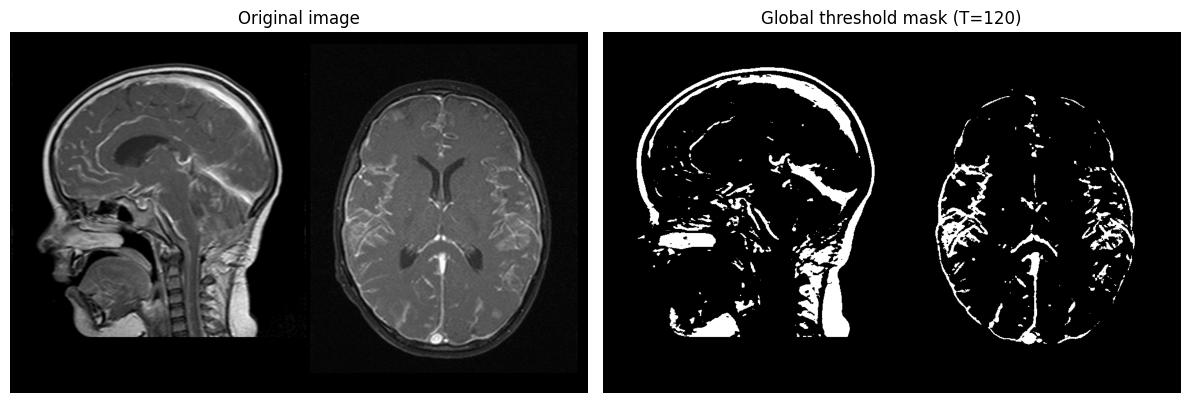

In [32]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image_path = "/content/cancer.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

def global_threshold(image, T):
    return (image >= T).astype(np.uint8)

T = 120
mask_global = global_threshold(image, T)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title(f"Original image")
axes[0].axis("off")

axes[1].imshow(mask_global, cmap="gray")
axes[1].set_title(f"Global threshold mask (T={T})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Task 2

In [33]:
def convolve2d(image, kernel):
    image = image.astype(np.float32)
    kernel = np.array(kernel, dtype=np.float32)
    image_path = "/content/cancer.jpg"

    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="edge")
    out = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel)

    return out

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

Gx = convolve2d(image, sobel_x)
Gy = convolve2d(image, sobel_y)
gradient_magnitude = np.sqrt(Gx**2 + Gy**2)

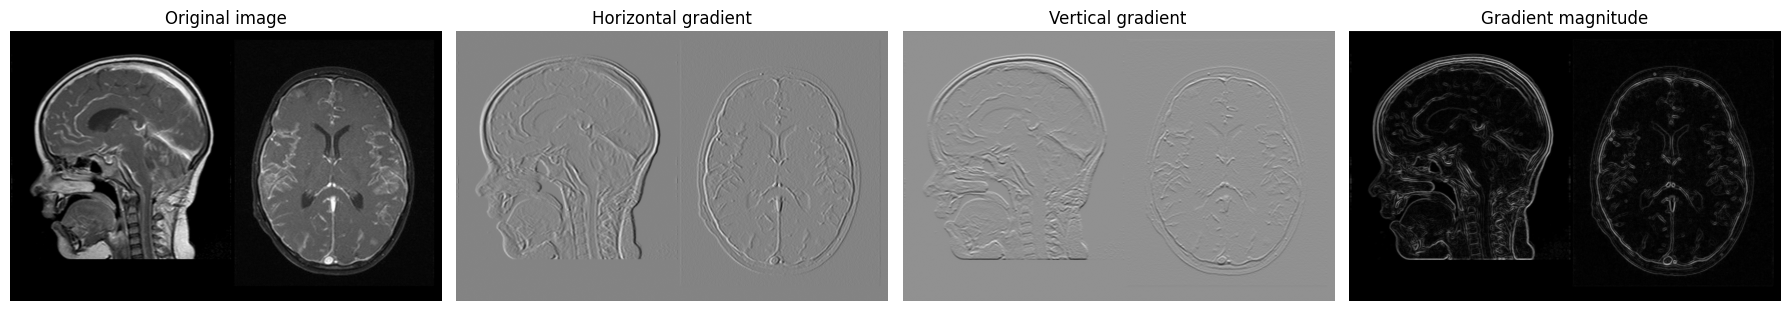

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(Gx, cmap="gray")
axes[1].set_title("Horizontal gradient")
axes[1].axis("off")

axes[2].imshow(Gy, cmap="gray")
axes[2].set_title("Vertical gradient")
axes[2].axis("off")

axes[3].imshow(gradient_magnitude, cmap="gray")
axes[3].set_title("Gradient magnitude")
axes[3].axis("off")

plt.tight_layout()
plt.show()

Task 3

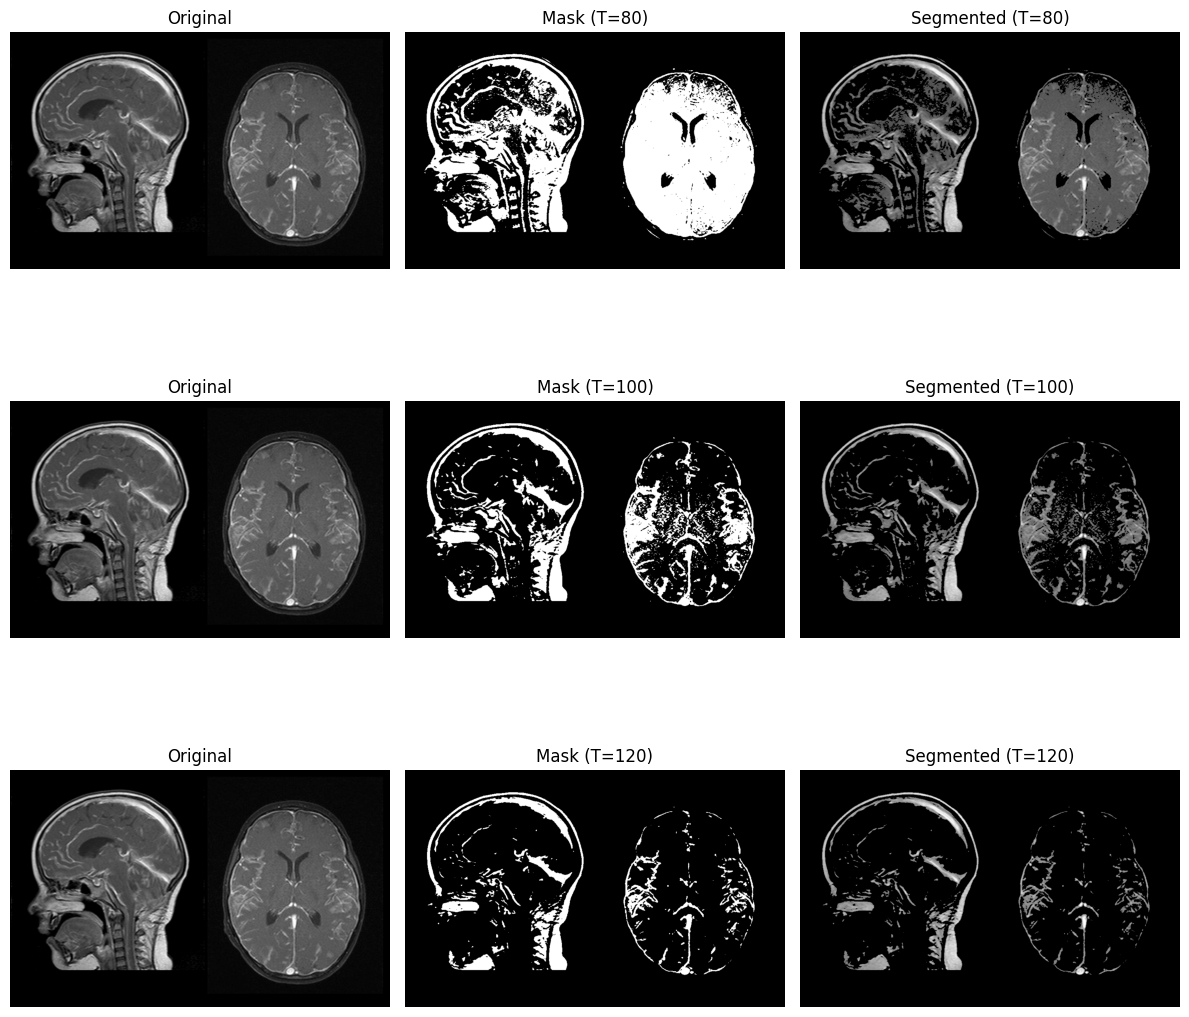

In [37]:

def segment_and_mask(image, threshold):
    mask = (image >= threshold).astype(np.uint8)
    segmented = image * mask
    return mask, segmented

image_path = "/content/cancer.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)


test_thresholds = [80, 100, 120]

fig, axes = plt.subplots(len(test_thresholds), 3, figsize=(12, 12))

for i, thr in enumerate(test_thresholds):
    mask, segmented = segment_and_mask(image, thr)

    axes[i, 0].imshow(image, cmap="gray")
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"Mask (T={thr})")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(segmented, cmap="gray")
    axes[i, 2].set_title(f"Segmented (T={thr})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()